In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [14]:
crypts = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :S => Float64,
        # :S_2 => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64,
        :Ds => Float64
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64
    ),

    medium = Dict(
        :mm => Float64,
        :ve => Float64
    ),

    agentODE = quote
  
        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]


        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        
        # X direction
        if x < xmin
            idx = Int(floor(Int, (x+(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)

        elseif x > xmax
            idx = Int(floor(Int, (x-(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)

        end

        # # Y direction
        if y < ymin
            idy = Int(floor(Int,(y+ymax-ymin)/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)

        elseif y > ymax
            idy = Int(floor(Int,(y-(ymax-ymin))/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)

        end

        mmb = max(0, mm[idx,idy])

        F = ε0 + ε1 * methyl + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka))
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)      

        mx = (ε0 + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) - F0) / (- ε1)
       

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))     

        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)     
        
    end,

    agentRule = quote

        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]

        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)        
       
     # Adding population every 100 steps
        p_add = 0.01

        if i1_ == 1
            if rand() < p_add
                for k in 1:10
                    @addAgent(
                        x = xmin + 10,
                        y = ymax/2 + 10 + rand()*(ymax - (ymax/2) - 10),
                        theta = 2 * pi,
                        l = 3
                    )
                end
            end
        end

        v_run = v
        v_tumble = 0.25 
        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        # mm[idx,idy] += S

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 
            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                  
            if P < P_rt             
                active = false
                vx = speed* cos(theta) + ve[idx, idy]*0.2
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn() 
                        
            else    
                active = true
                vx = speed * cos(theta) + ve[idx, idy]*0.2
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
                     
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta) + ve[idx, idy]*0.2
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()

            else
                active = false
                vx = speed* cos(theta) + ve[idx, idy]*0.2
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()

            end
        end

        if x <= xmin
            x = xmin + (xmin - x)
            theta = pi - theta
        elseif x >= xmax
            @removeAgent()
        end

        if y >= 750
            y = 2*ymax - y
            theta = 2*pi - theta
        end

        if y <= wall_y(x, 70, 200, 500, 20, 1000)
            x_new = clamp(round(Int, x/2), 1, 500)
            y_new = clamp(round(Int, y/2), 1, 500)

            if MYT[x_new, y_new] == 1 && MXR[x_new, y_new] == 1
                y = wall_y(x, 70, 200, 500, 20, 1000) + 1
                x = x + 1
                theta = theta + pi

            elseif MYT[x_new, y_new] == 1 && MXL[x_new, y_new] == 1
                y = wall_y(x, 70, 200, 500, 20, 1000) + 1
                x = x - 1
                theta = theta + pi

            elseif MYT[x_new, y_new] == 1 
                y = wall_y(x, 70, 200, 500, 20, 1000) + 1
                theta = 2*pi - theta

            elseif MXR[x_new, y_new] == 1
                x = x + 2
                theta = pi - theta

            elseif MXL[x_new, y_new] == 1
                x = x - 2
                theta = pi - theta

            elseif M0[x_new, y_new] == 1        # Esta dins, no pinta res allí
                t0 = round(Int, (t-1))
                x_old = x[t0]
                y_old = y[t0]
                nsteps = ceil(Int, max(abs(x - x_old), abs(y - y_old)))

                hit_type = nothing

                for s in 0:nsteps
                    xs = x_old + (x - x_old) * s / nsteps
                    ys = y_old + (y - y_old) * s / nsteps

                    xi = clamp(round(Int, xs/2), 1, 250)
                    yi = clamp(round(Int, ys/2), 1, 250)

                    if MXR[xi, yi]
                        hit_type = :right
                        break
                    elseif MXL[xi, yi]
                        hit_type = :left
                        break
                    elseif MYT[xi, yi]
                        hit_type = :horizontal
                        break
                    end
                end
                if hit_type == :right
                    x = x_old
                    theta = pi - theta

                elseif hit_type == :left
                    x = x_old
                    theta = pi - theta

                elseif hit_type == :horizontal
                    y = y_old
                    theta = 2*pi - theta
                end
                                
            end
        end
    end,


    mediumODE = quote

        if @mediumInside()
    # --- geometry mask FIRST (do NOT overwrite mm itself) ---
            if M0[i1_, i2_]
                dt(mm) = 0

            elseif MB[i1_, i2_]
                dt(mm) = 0

            else
                dt(mm) = DMedium * (@∂2(1, mm) + @∂2(2, mm)) - delta * mm - ve[i1_, i2_] * @∂(1, mm)

            end
            # mm = MXR[i1_, i2_] ? mm[i1_ + 1, i2_] : mm
            # mm = MXL[i1_, i2_] ? mm[i1_ - 1, i2_] : mm
            # mm = MYT[i1_, i2_] ? mm[i1_, i2_ + 1] : mm

            mm = MB[i1_, i2_ + 1] ? mm[i1_, i2_ - 1] : mm # Reflective quan toca maya de sobre?
            mm = MXR[i1_, i2_] ? S : mm
            mm = MXL[i1_, i2_] ? S : mm
            mm = MYT[i1_, i2_] ? S : mm
            
        elseif @mediumBorder(1,-1) # left PBC
            mm = mm[1, i2_]

        elseif @mediumBorder(1,1) #right PBC
            mm = mm[NMedium[1] - 1, i2_]

        elseif @mediumBorder(2,-1) # down 0
            mm = 0

        elseif @mediumBorder(2,+1)
            mm = 0

        end
    end,


    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler()
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	Ds (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)
	ve (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()
    if

In [3]:
function wall_y(x, w, d, y0, xstart, xend)
    
    # outside wall region → flat at baseline
    if x < xstart || x > xend
        return y0
    end

    # shift x so pattern starts at xstart
    ξ = x - xstart

    # square-wave pattern (0 or -d), then shift up by y0
    return y0 - d * floor((1 + sign(sin(2π * ξ / w))) / 2)
end

wall_y (generic function with 1 method)

In [10]:
x1, x2, y1, y2 = 0, 1000, 0, 1000
med1, med2 = 500, 500

width = 70
depth = 200
y_start = y2/2
x_start = 20
x_end = x2
dx = (x2 - x1) / med1
dy = (y2 -y1) / med2

xcoord(i1_) = x1 + (i1_ - 1) * dx
ycoord(i2_) = y1 + (i2_ - 1) * dy
Nx = med1
Ny = med2

mask_raw = zeros(Bool, med1, med2)
M0 = zeros(Bool, med1, med2)
MXL = zeros(Bool, med1, med2)
MXR = zeros(Bool, med1, med2)
MYT = zeros(Bool, med1, med2)

for i in 1:Nx, j in 1:Ny
    x = xcoord(i)
    y = ycoord(j)
    mask_raw[i,j] = y < wall_y(x, width, depth, y_start, x_start, x_end)
end

for i in 2:Nx-1, j in 2:Ny-1
    if mask_raw[i,j] &&
    mask_raw[i+1,j] &&
    mask_raw[i-1,j] &&
    mask_raw[i,j+1] &&
    mask_raw[i,j-1] &&
    mask_raw[i+1,j+1] &&
    mask_raw[i+1,j-1] &&
    mask_raw[i-1,j+1] &&
    mask_raw[i-1,j-1]

        M0[i,j] = true
    end
end

M0[1,   :] .= true
M0[500, :] .= true
M0[1,   250:end] .= false
M0[500, 250:end] .= false
M0[:, 1] .= true

for i in 2:Nx-1, j in 2:Ny-1

    if M0[i,j] == 1

                # --- HORIZONTAL LINES ---
                # bottom edge (neighbor below is outside)
        if M0[i, j-1] == 0
            MYT[i,j] = true
        end

                # top edge (neighbor above is outside)
        if M0[i, j+1] == 0
            MYT[i,j] = true
        end


                # --- LEFT WALL ---
        if M0[i-1, j] == 0
            MXL[i,j] = true
        end


                # --- RIGHT WALL ---
        if M0[i+1, j] == 0
            MXR[i,j] = true
        end

    end
end

MYT[1,   248:249] .= true
MYT[500,   248:249] .= true

MB = zeros(Bool, 500, 500)
MB[:, 375:500] .= true

500×126 view(::Matrix{Bool}, :, 375:500) with eltype Bool:
 1  1  1  1  1  1  1  1  1  1  1  1  1  …  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  …  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 ⋮              ⋮              ⋮        ⋱     ⋮              ⋮              ⋮
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1

In [ ]:
com = Community(
    crypts,
    N=1000,
    dt=0.01,
    # simBox = [-100.0 100.0; -100.0 100.0],
    simBox = [0.0 1000.0; 0.0 1000.0],
    # simBox = [0.0 200.0; 0.0 200.0],
    NMedium = [500,500]
    # NMedium = [100,100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

com.v = 20.0    #Velocitat bacteries biològica
# com.v = 10.0
# com.v = 0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 5
# com.DMedium = 20
com.delta = 0.005
# com.delta = 0.00125

com.x = zeros(com.N)
com.y = zeros(com.N)

count = 0

while count < com.N
    x_try = rand(Uniform(0, 750))   ## Limit 750 remember
    y_try = rand(Uniform(com.simBox[2,:]...))

    # map to mask indices
    i = Int(floor(x_try / 2)) + 1
    j = Int(floor(y_try / 2)) + 1

    # bounds safety
    if i < 1 || i > y_start || j < 1 || j > y_start
        continue
    end

    if M0[i, j] == 0
        count += 1
        com.x[count] = x_try
        com.y[count] = y_try
    end
end

com.theta = rand(Uniform(0, 2*pi),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 

com.S = 0.0025

com.ve = zeros(com.NMedium[1], com.NMedium[2])

L = 100.0   # thickness of transition layer (tune this)

for i1 in 1:com.NMedium[1], i2 in 1:com.NMedium[2]
    y = ycoord(i2)

    if y <= y_start
        # Inside crypt → no flow
        com.ve[i1, i2] = 0.0

    elseif y < y_start + L
        # Transition region → smooth increase
        f = (y - y_start) / L
        com.ve[i1, i2] = 10.0 * f^2

    else
        # Bulk lumen → full flow
        com.ve[i1, i2] = 10.0
    end
end

In [16]:
outfile = "c_box.jld2"
steps = 25000

loadToPlatform!(com, preallocateAgents=1000)
com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    for step in 1:steps
        CellBasedModels.step!(com)
        if step%500 == 0

            stepname = @sprintf("step_%06d", step)
            g = JLD2.Group(file, stepname)

            # Agent-level arrays (length = N)
            g["x"] = copy(com.x)
            g["y"] = copy(com.y)
            g["theta"] = copy(com.theta)

            # Medium grid (saved once per step)
            g["mm_grid"] = copy(com.mm)
            
        end
    end
end


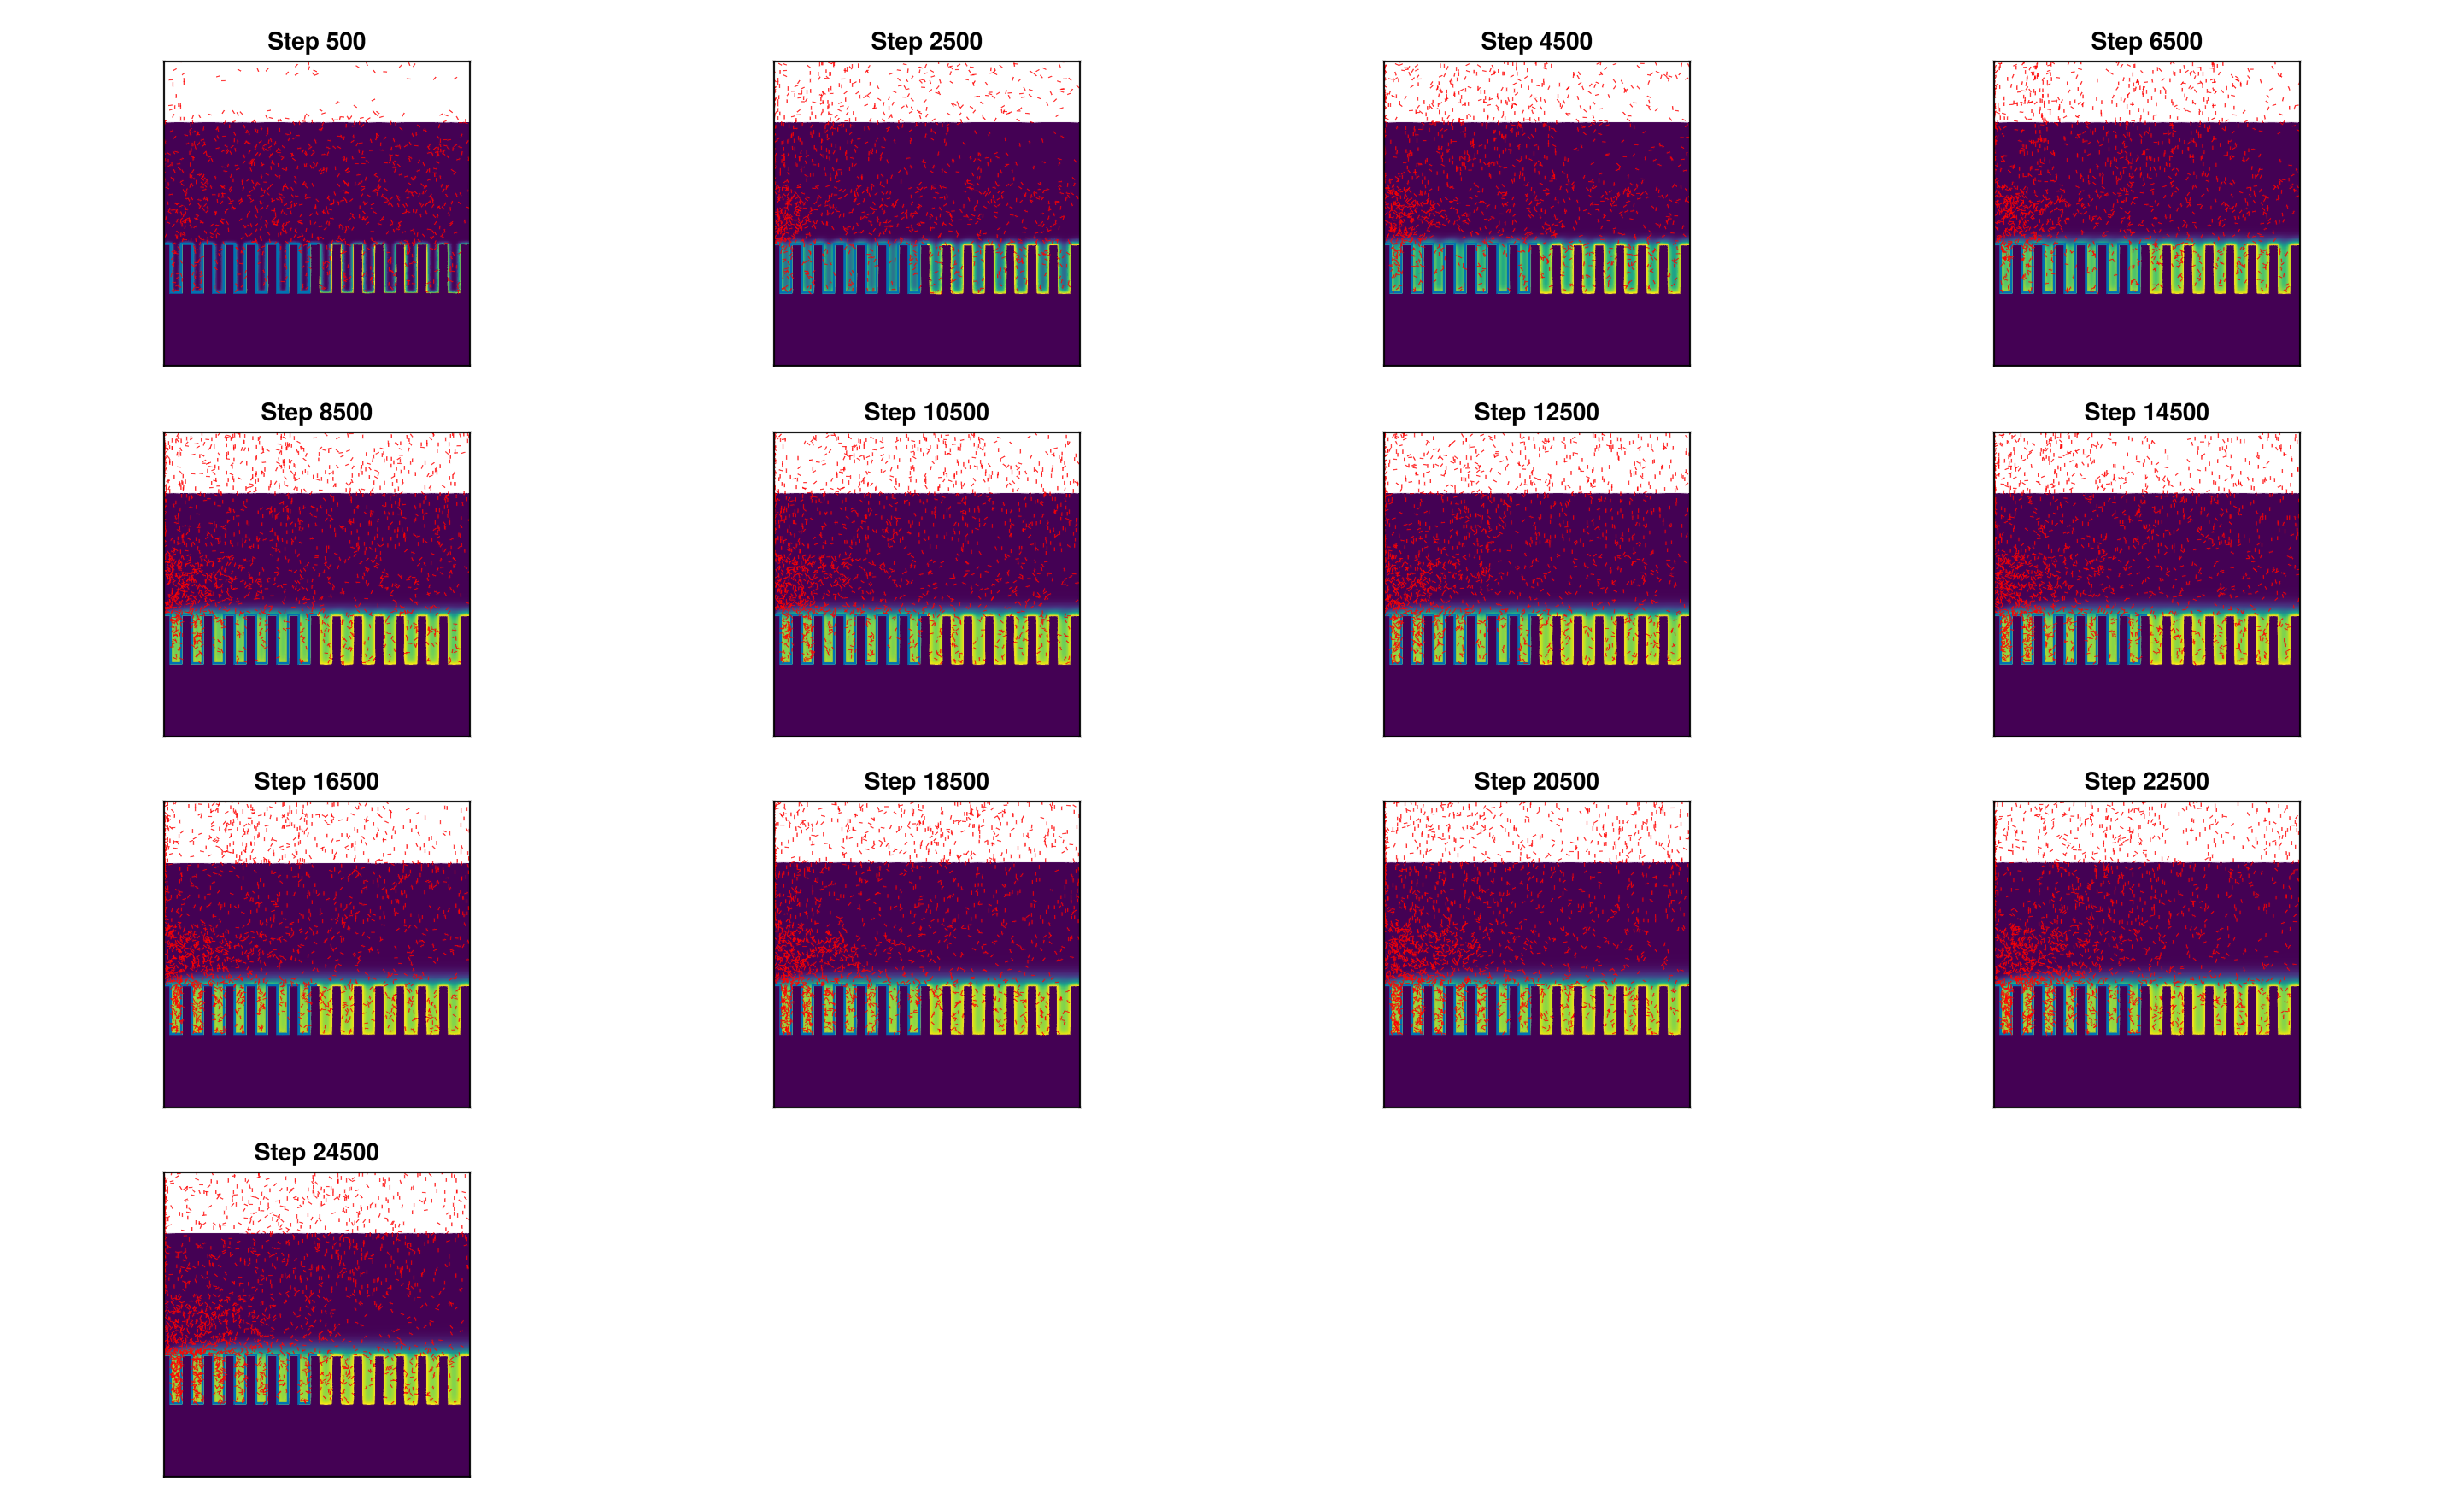

GLMakie.Screen(...)

In [18]:
fig4 = Figure(size=(900*4,600*4))
# steps = 5000
model_steps = 500:500:25000
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/12):end]

jldopen("c_box.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        row = ceil(Int, j / 4)
        col = (j - 1) % 4 + 1
        # col1 = columns[j]
        ax = Axis(fig4[row, col], aspect = 1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (com.NMedium[1], com.NMedium[2]))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        xs = 0:0.1:500
        ys = [wall_y(x, width, depth, y_start, 20, x_end) for x in xs]

        lines!(ax, xs, ys)


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            if x[i] != 0
                linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
                linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
            end
        end
        hidedecorations!(ax)

        # Colorbar(fig4[1, j*2], hm, label="Chemoattractant")

    end
end
Makie.inline!(true)
display(fig4)

# Save grid initialize

In [27]:
data = Dict{Int, Any}()
steps = 20000
jldopen("c_box.jld2", "r") do file
    key = file[@sprintf("step_%06d", step)]
    data[step] = Dict("mm_grid" => copy(key["mm_grid"])
        )
end

Dict{String, Matrix{Float64}} with 1 entry:
  "mm_grid" => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 2.87676e-77 0.0; … ; 0.0 0.0 … 2.7…

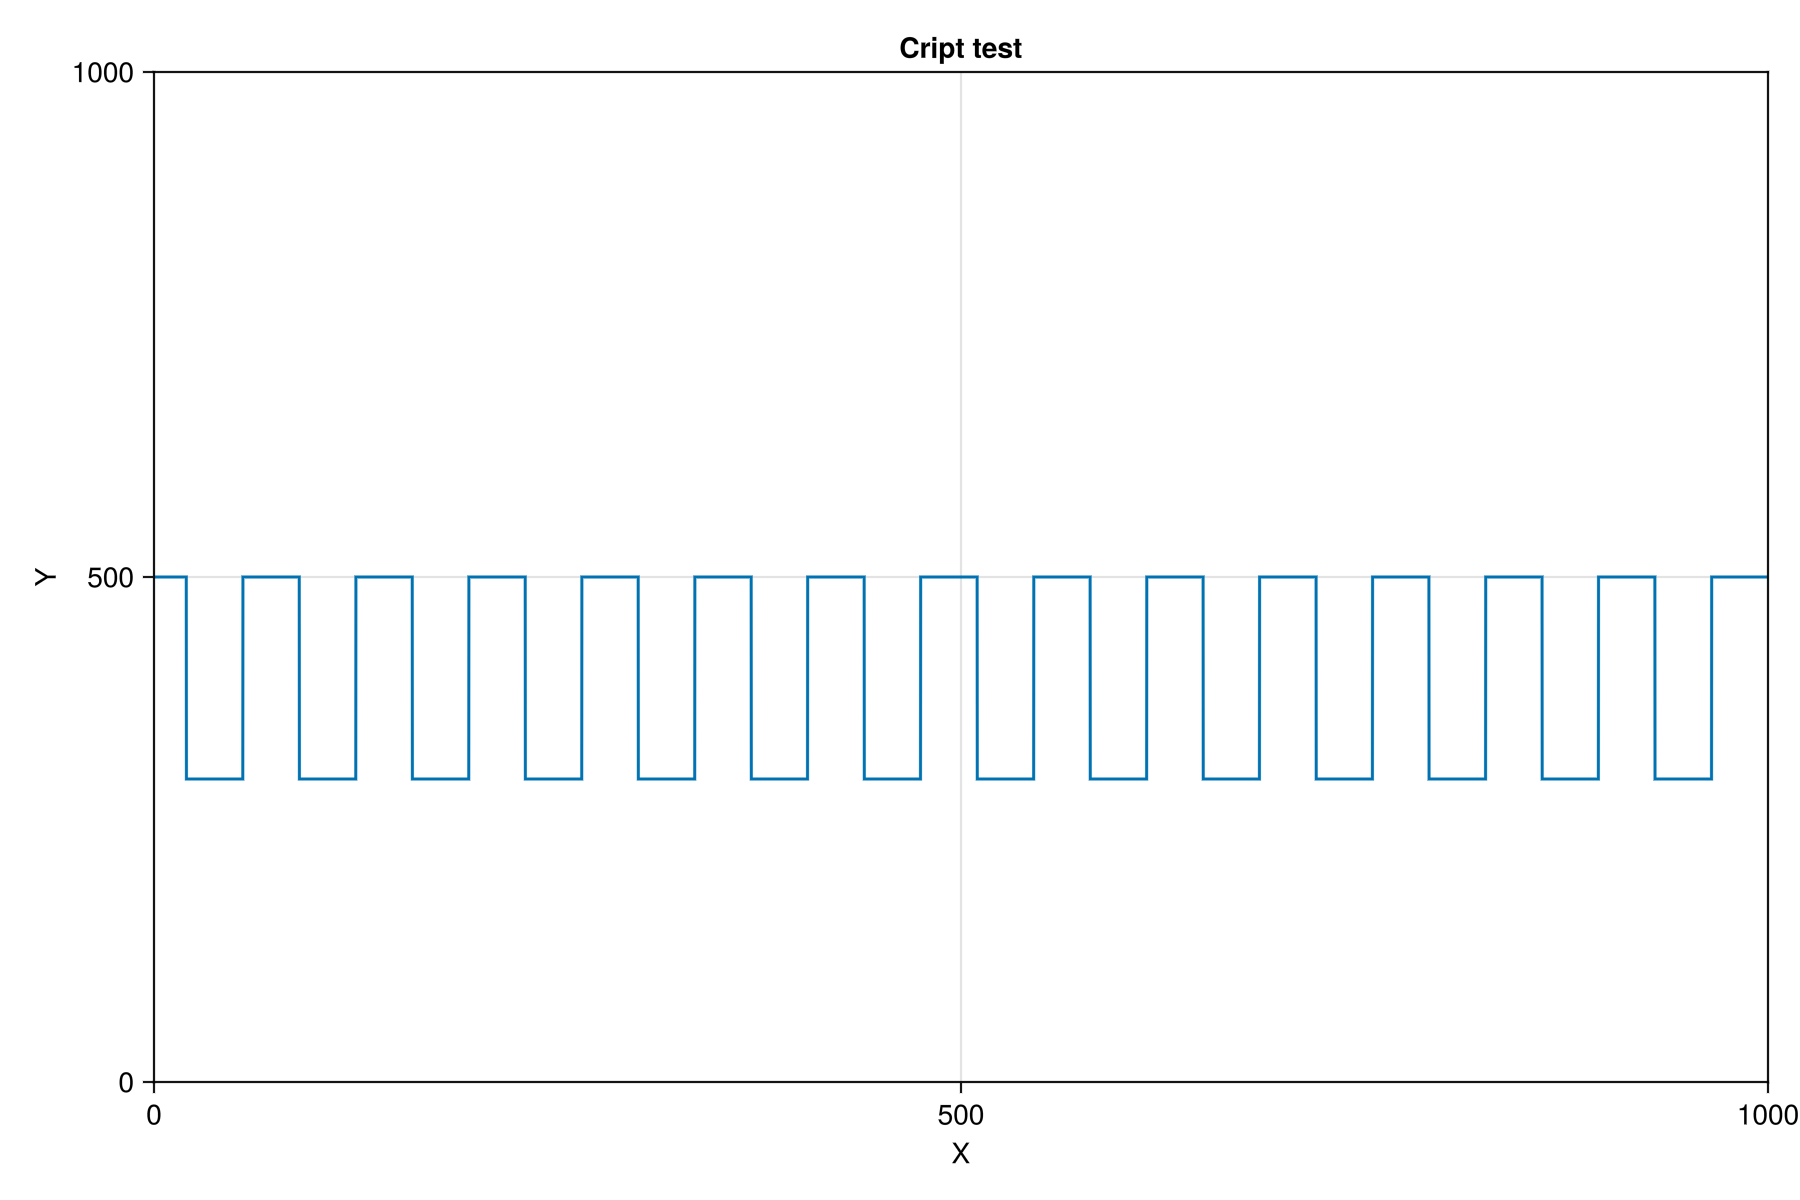

In [72]:
fig = Figure(size=(900,600))
ax = Axis(fig[1,1], title = "Cript test", xlabel = "X", ylabel = "Y")

xs = 0:0.1:1000
ys = [wall_y(x, 70, 200, 500, 20, 1000) for x in xs]
# ys1 = [wall_y(x, 62, 100, 250, 20, 500) for x in xs]

lines!(ax, xs, ys)
# lines!(ax, xs, ys1)
xlims!(ax, 0, 1000)
ylims!(ax, 0, 1000)
fig

In [52]:
MYT[1,   248:249] .= true
MYT[500,   248:249] .= true

2-element view(::Matrix{Bool}, 500, 248:249) with eltype Bool:
 1
 1

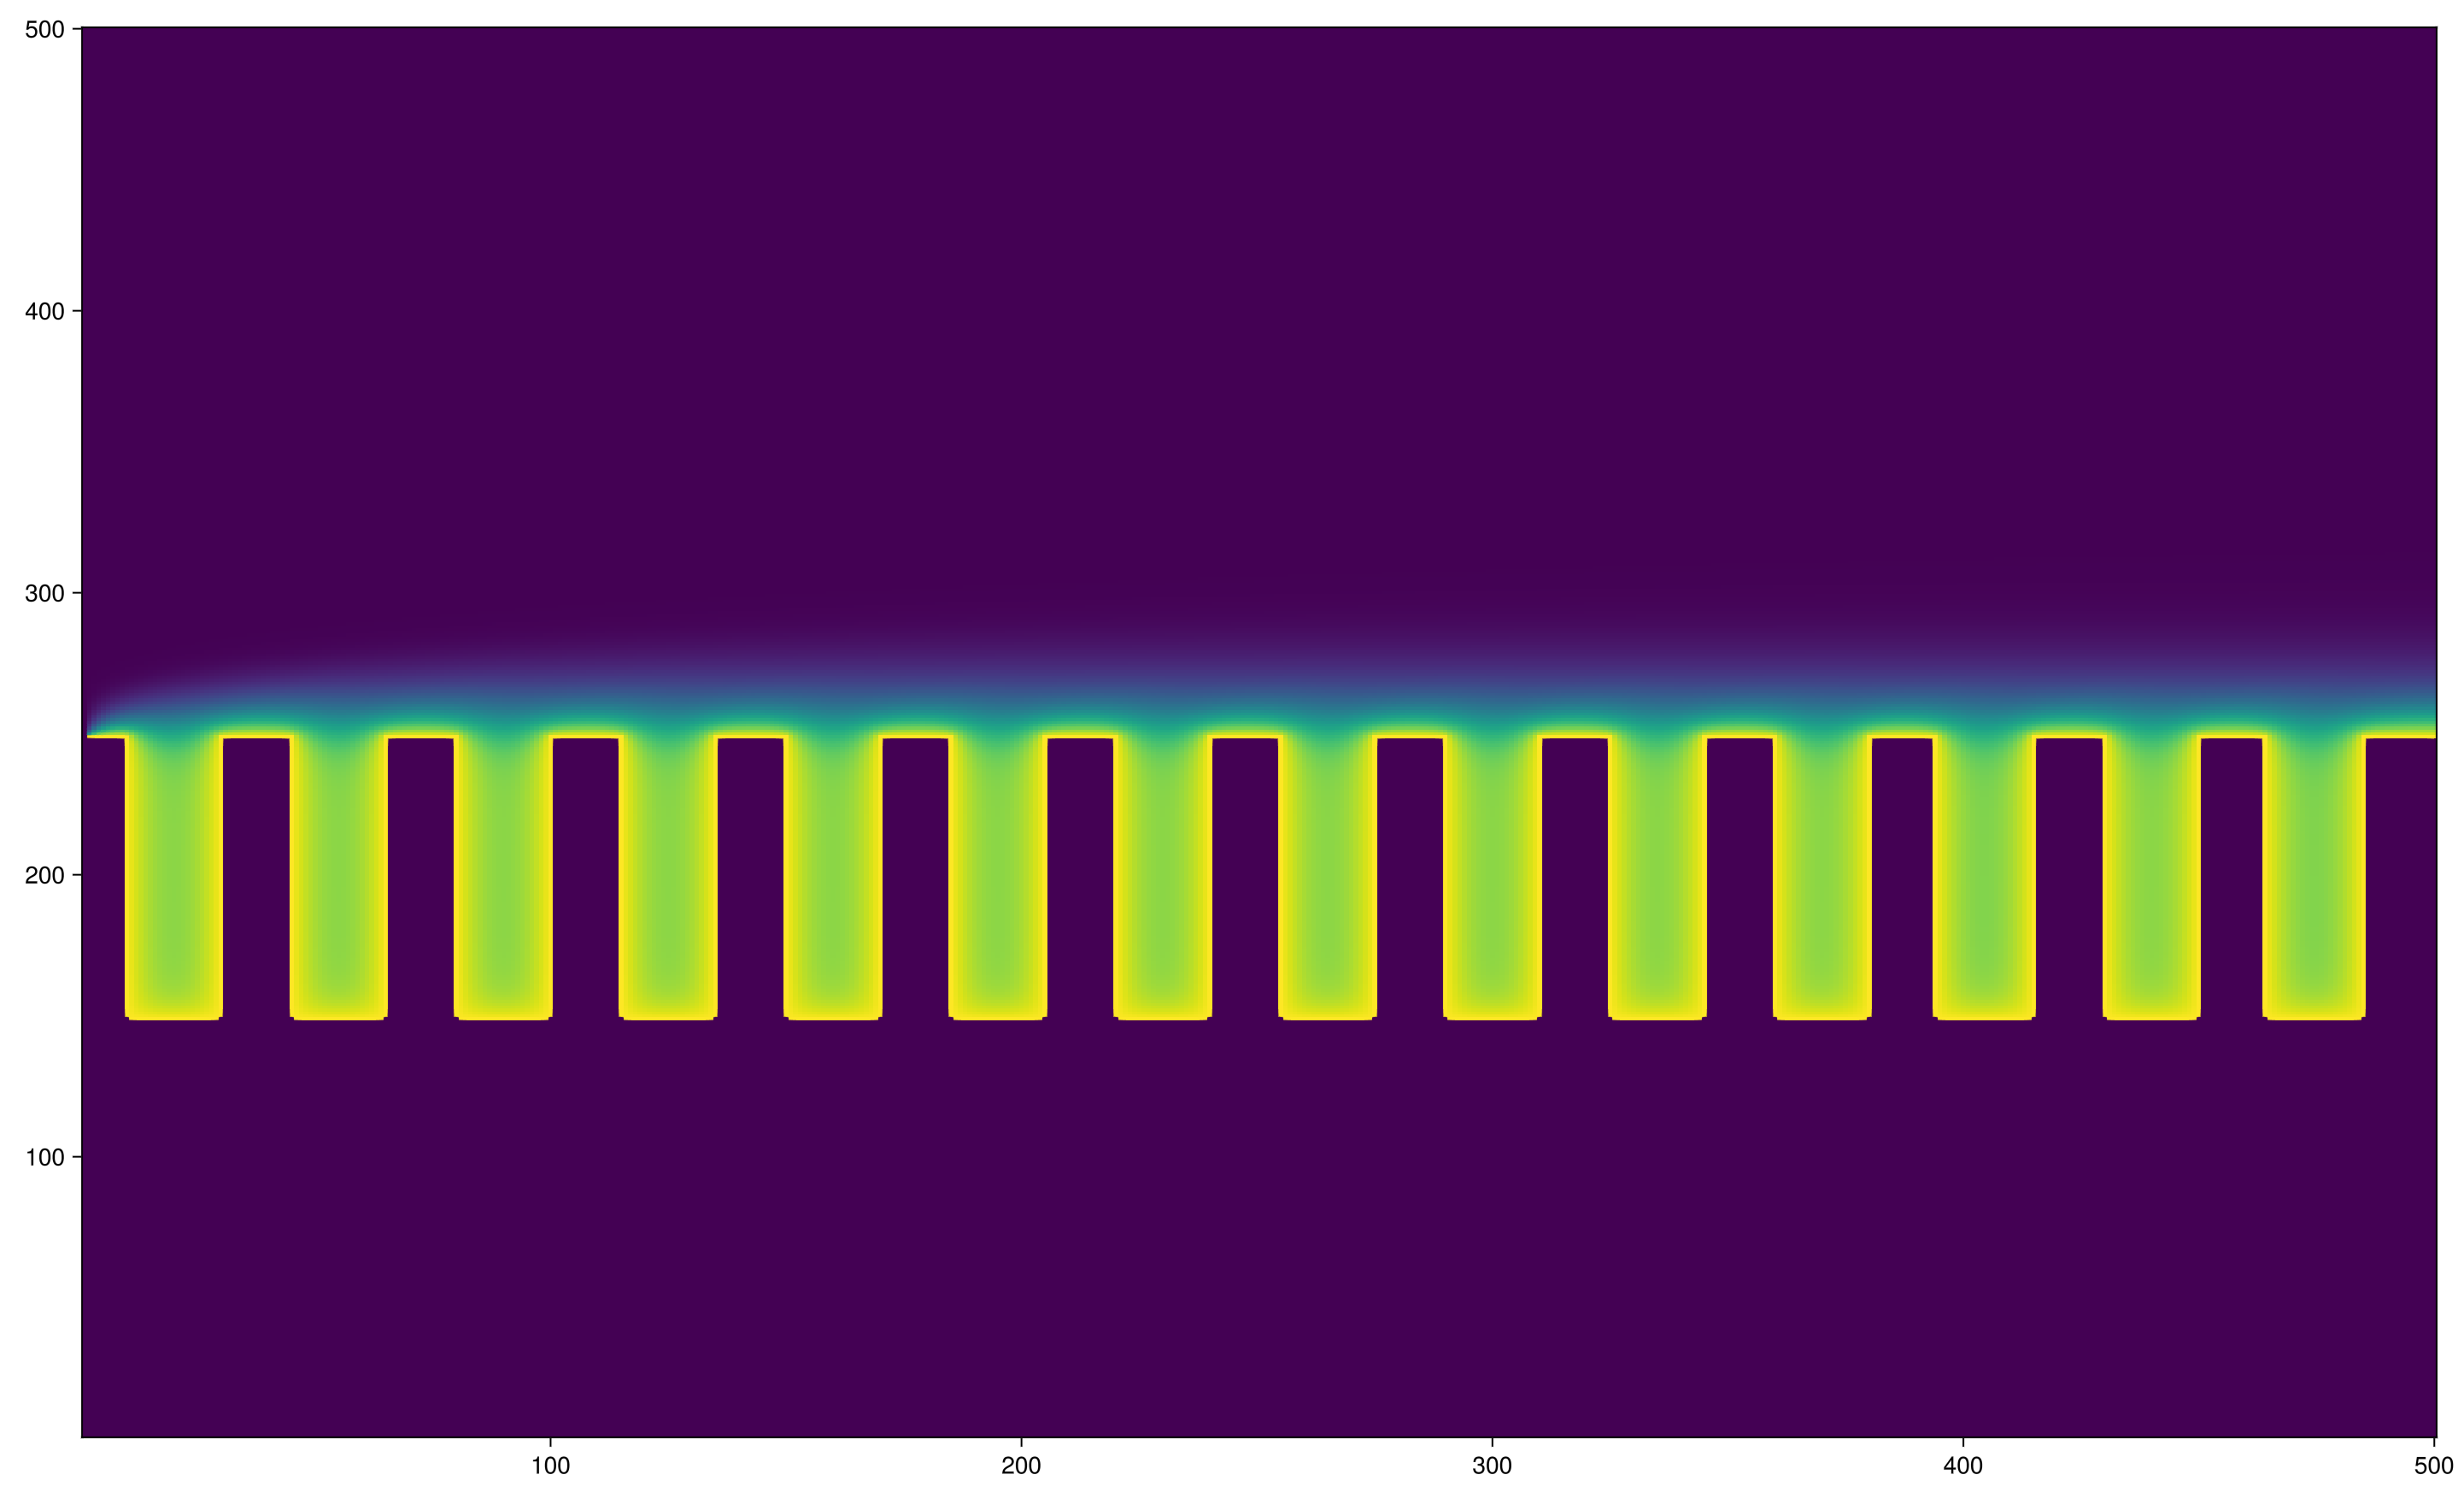

In [33]:
fig3 = Figure(size=(2100,1200))
ax3 = Axis(fig3[1,1])
# ax3_2 = Axis(fig3[1,2])
# ax3_3 = Axis(fig3[2,1])
# ax3_4 = Axis(fig3[2,2])
hm = heatmap!(ax3, mm_grid, colormap = :viridis)
# hm_1 = heatmap!(ax3_2, MXL1)
# hm_2 = heatmap!(ax3_3, MXR)
# hm_3 = heatmap!(ax3_4, MXR1)
# contour!(ax3_2, M0, linewidth = 0.5)
# contour!(ax3_3, M0, linewidth = 0.5)
# contour!(ax3, MXR, linewidth = 0.5)
# contour!(ax3, MXL, linewidth = 0.5)
# contour!(ax3, MYT, linewidth = 0.5)
# xs = 0:1:250
# ys = 0:1:250
# vector = repeat([125], inner=length(xs))
# vector1 = repeat([75], inner=length(xs))
# vector1 = repeat([10], inner=length(xs))
# ys = [wall_bottom(x,10, 200, 110, 100) for x in xs]
# lines!(ax3, xs, vector)
# lines!(ax3_2, xs, vector)
# lines!(ax3_3, xs, vector)
# lines!(ax3_4, vector1, ys)
# lines!(ax3_2, vector1, ys)
# lines!(ax3_4, xs, vector)
# lines!(ax3, xs, vector1)
# lines!(ax3_2, xs, vector1)
# lines!(ax3_3, xs, vector1)
# lines!(ax3_4, xs, vector1)
# hm = heatmap!(ax3, Z)
Makie.inline!(true)

fig3

In [34]:
@save "500_n_2_S_0025.jld2" mm_grid

In [32]:
mm_grid

500×500 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …   0.0           0.0          0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0      2.87676e-77   2.87676e-77  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0      5.36898e-75   5.36898e-75  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0      7.98697e-75   7.98697e-75  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -1.21672e-74  -1.21672e-74  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -2.33826e-74  -2.33826e-74  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0      3.00902e-74   3.00902e-74  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0      1.25339e-73   1.25339e-73  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -8.28495e-74  -8.28495e-74  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -3.57434e-73  -3.57434e-73  0.0
 ⋮                        ⋮              ⋱                              
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0      2.12073e-13   2.12073e-13  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0      2.19557e-13   2.19557